# Analyse measurements taken on the lsm6ds3

We start with a measurement, where the lsm6ds3 lies horizontally on a table

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def readMeasurementFile(filename):
    file = open(filename,"r")
    all = file.read()
    cnt = []
    acc = []
    gyro = []
    lines = all.split("\n")
    # print(len(lines))
    for i in range(len(lines)-1):
        tmp1 = lines[i].split(":")
        cnt.append(int(tmp1[0]))
        tmp2 = tmp1[1].split("|")
        tmp3 = tmp2[0].split(",")
        tmp4 = tmp2[1].split(",")
        gyro.append([float(tmp3[0]),float(tmp3[1]),float(tmp3[2])])
        acc.append([float(tmp4[0]),float(tmp4[1]),float(tmp4[2])])
    return gyro,acc
    # print("cnt: ",cnt)
    # print("gyro: ",gyro)
    # print("acc: ",acc)
    

### Interpreting measured data when the lsm6ds3 lies horizontally on a table
Since there is no movement, the gyro values should all be zero. There is however an offset, which can be determined by this
measurement and later be subtracted.  
The accelerometer data expected, are zero for the x and y component and 1g for the z component. z points to the center of the earth or to the sky. Again offsets can be determined for later subtraction.

In [3]:
gyro_data, acc_data = readMeasurementFile("data/horizontal.dat")

In [4]:
gyro_plt = (np.array(gyro_data)[:,0], 
            np.array(gyro_data)[:,1], 
            np.array(gyro_data)[:,2])

Plot the gyroscope and accelerometer measurements

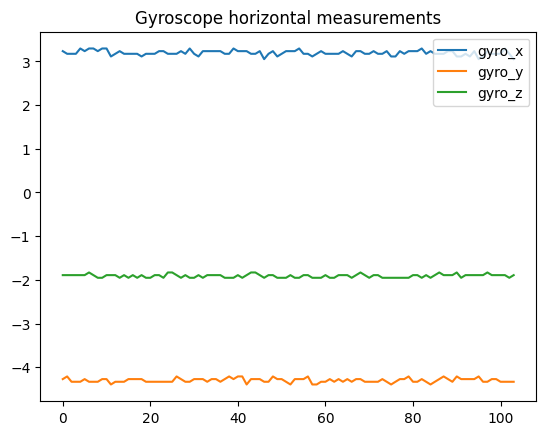

In [5]:
plt.title("Gyroscope horizontal measurements")
plt.plot(gyro_plt[0],label="gyro_x")
plt.plot(gyro_plt[1],label="gyro_y")
plt.plot(gyro_plt[2],label="gyro_z")
plt.legend(loc="upper right")

Calculate the offset by averaging over the measure gyro values

In [6]:
gyro_offsets = [0,0,0]
for i in range(3):
    for j in range(len(gyro_data)):
        gyro_offsets[i] += gyro_data[j][i]
for i in range(3):
    gyro_offsets[i] /= len(gyro_data)
print("Gyroscope offsets: ",gyro_offsets)

Gyroscope offsets:  [3.1957019230769257, -4.300221153846158, -1.9101826923076917]


Let's  correct for the offsets and plot the correct gyro data

In [7]:
for i in range(len(gyro_data)):
    for j in range(3):
        gyro_data[i][j]-= gyro_offsets[j]

In [8]:
gyro_plt = (np.array(gyro_data)[:,0], 
            np.array(gyro_data)[:,1], 
            np.array(gyro_data)[:,2])

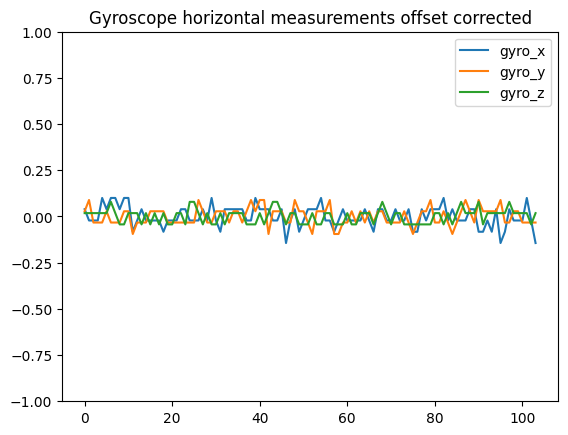

In [9]:
plt.title("Gyroscope horizontal measurements offset corrected")
ax = plt.gca()
ax.set_ylim([-1, 1])
plt.plot(gyro_plt[0],label="gyro_x")
plt.plot(gyro_plt[1],label="gyro_y")
plt.plot(gyro_plt[2],label="gyro_z")
plt.legend(loc="upper right")

The same thing for the accelerometer data

In [6]:
acc_plt = (np.array(acc_data)[:,0], 
           np.array(acc_data)[:,1], 
           np.array(acc_data)[:,2])

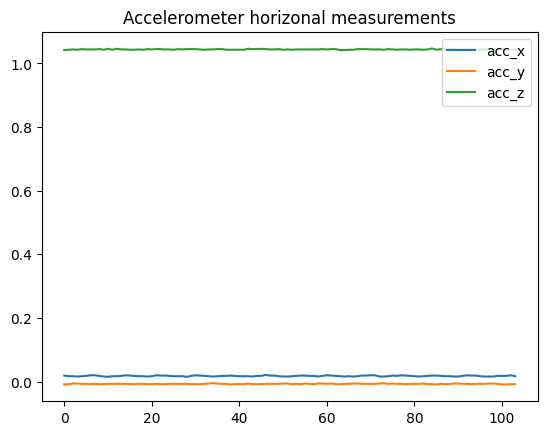

In [7]:
plt.title("Accelerometer horizonal measurements")
plt.plot(acc_plt[0],label="acc_x")
plt.plot(acc_plt[1],label="acc_y")
plt.plot(acc_plt[2],label="acc_z")
plt.legend(loc="upper right")

In [12]:
acc_offsets = [0,0,0]
for i in range(3):
    for j in range(len(acc_data)):
        acc_offsets[i] += acc_data[j][i]
for i in range(3):
    acc_offsets[i] /= len(acc_data)
acc_offsets[2] -= 1
print("Accelerometer offsets: ",acc_offsets)

Accelerometer offsets:  [0.01774999999999999, -0.007173076923076929, 0.04403846153846169]


In [13]:
print("gravity when the wand is orientated vertically: ",acc_offsets)

gravity when the wand is orientated vertically:  [0.01774999999999999, -0.007173076923076929, 0.04403846153846169]


In [14]:
acc_plt = (np.array(acc_data)[:,0], 
           np.array(acc_data)[:,1], 
           np.array(acc_data)[:,2])

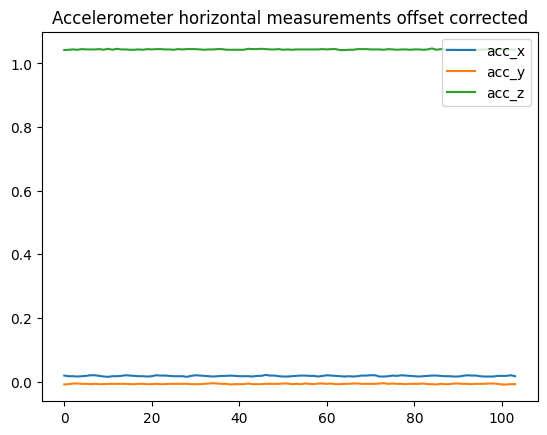

In [15]:
plt.title("Accelerometer horizontal measurements offset corrected")
plt.plot(acc_plt[0],label="acc_x")
plt.plot(acc_plt[1],label="acc_y")
plt.plot(acc_plt[2],label="acc_z")
plt.legend(loc="upper right")

## Data when the magic wand is orientated vertically

Again we expect zero gyroscope values since the gyroscope is not moving

In [16]:
gyro_data, acc_data = readMeasurementFile("data/vertical.dat")

In [17]:
gyro_plt = (np.array(gyro_data)[:,0], 
            np.array(gyro_data)[:,1], 
            np.array(gyro_data)[:,2])

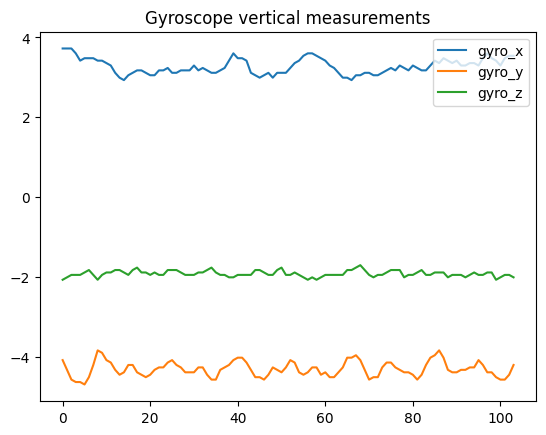

In [18]:
plt.title("Gyroscope vertical measurements")
plt.plot(gyro_plt[0],label="gyro_x")
plt.plot(gyro_plt[1],label="gyro_y")
plt.plot(gyro_plt[2],label="gyro_z")
plt.legend(loc="upper right")

In [19]:
gyro_offsets = [0,0,0]
for i in range(3):
    for j in range(len(gyro_data)):
        gyro_offsets[i] += gyro_data[j][i]
for i in range(3):
    gyro_offsets[i] /= len(gyro_data)
print("Gyroscope offsets: ",gyro_offsets)

Gyroscope offsets:  [3.273125000000002, -4.3152596153846146, -1.9230865384615394]


In [20]:
acc_plt = (np.array(acc_data)[:,0], 
           np.array(acc_data)[:,1], 
           np.array(acc_data)[:,2])

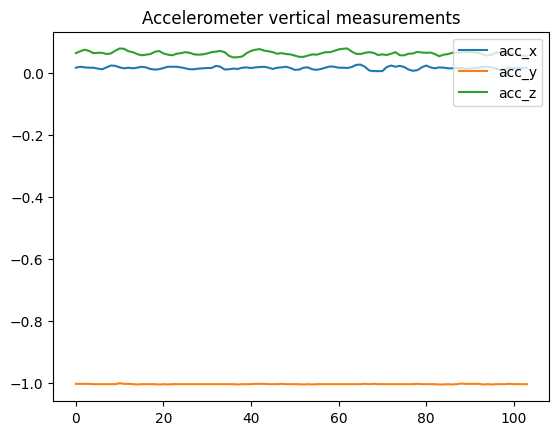

In [21]:
plt.title("Accelerometer vertical measurements")
plt.plot(acc_plt[0],label="acc_x")
plt.plot(acc_plt[1],label="acc_y")
plt.plot(acc_plt[2],label="acc_z")
plt.legend(loc="upper right")

In [23]:
acc_offsets = [0,0,0]
for i in range(3):
    for j in range(len(acc_data)):
        acc_offsets[i] += acc_data[j][i]
for i in range(3):
    acc_offsets[i] /= len(acc_data)
print("Accelerometer offsets: ",acc_offsets)

Accelerometer offsets:  [0.015230769230769218, -1.0048846153846152, 0.06285576923076924]


While there is little change in the gyroscope values, which is to be expected because there is no angular 
movement, there is a substantial change in the accelerometer data.  
Now the x and z values are zero and only the y axis sees the effect of gravitation.

### 45° measurement

In [ ]:
gyro_data, acc_data = readMeasurementFile("data/45degrees.dat")

In [ ]:
acc_plt = (np.array(acc_data)[:,0], 
           np.array(acc_data)[:,1], 
           np.array(acc_data)[:,2])

In [ ]:
plt.title("Accelerometer measurements at 45°")
plt.plot(acc_plt[0],label="acc_x")
plt.plot(acc_plt[1],label="acc_y")
plt.plot(acc_plt[2],label="acc_z")
plt.legend(loc="upper right")

In [ ]:
from math import sin,cos,radians
print("sin(45°): {:4.2f}, cos(45°): {:4.2f}".format(sin(radians(45)),cos(radians(45))))

In [ ]:
acc_offsets = [0,0,0]
for i in range(3):
    for j in range(len(acc_data)):
        acc_offsets[i] += acc_data[j][i]
for i in range(3):
    acc_offsets[i] /= len(acc_data)
print("Averaged accelerometer values: ",acc_offsets)

### 30° measurement

In [ ]:
gyro_data, acc_data = readMeasurementFile("data/30degrees.dat")

In [ ]:
acc_plt = (np.array(acc_data)[:,0], 
           np.array(acc_data)[:,1], 
           np.array(acc_data)[:,2])

In [ ]:
plt.title("Accelerometer measurements at 30°")
plt.plot(acc_plt[0],label="acc_x")
plt.plot(acc_plt[1],label="acc_y")
plt.plot(acc_plt[2],label="acc_z")
plt.legend(loc="upper right")

In [ ]:
print("sin(30°): {:4.2f}, cos(30°): {:4.2f}".format(sin(radians(30)),cos(radians(30))))

In [ ]:
acc_offsets = [0,0,0]
for i in range(3):
    for j in range(len(acc_data)):
        acc_offsets[i] += acc_data[j][i]
for i in range(3):
    acc_offsets[i] /= len(acc_data)
print("Averaged accelerometer values: ",acc_offsets)

In [ ]:
### 60° measurement

In [ ]:
gyro_data, acc_data = readMeasurementFile("data/60degrees.dat")

In [ ]:
acc_plt = (np.array(acc_data)[:,0], 
           np.array(acc_data)[:,1], 
           np.array(acc_data)[:,2])

In [ ]:
plt.title("Accelerometer measurements at 60°")
plt.plot(acc_plt[0],label="acc_x")
plt.plot(acc_plt[1],label="acc_y")
plt.plot(acc_plt[2],label="acc_z")
plt.legend(loc="upper right")

In [ ]:
print("sin(60°): {:4.2f}, cos(60°): {:4.2f}".format(sin(radians(60)),cos(radians(60))))

In [ ]:
acc_offsets = [0,0,0]
for i in range(3):
    for j in range(len(acc_data)):
        acc_offsets[i] += acc_data[j][i]
for i in range(3):
    acc_offsets[i] /= len(acc_data)
print("Averaged accelerometer values: ",acc_offsets)